# SIT720 8.1D — Sydney Housing Price Prediction and Decision Support System

**End-to-end project notebook**

This notebook covers the complete workflow for the distinction task:

1. Data understanding and quality
2. Exploratory data analysis and feature engineering
3. Three contrasting regression models and cross-validation
4. Largest prediction-error investigation
5. Ten-property held-out comparison framework for ML, LLM and human estimates
6. Streamlit prediction application and deployment preparation

> **Academic integrity:** This notebook provides an analysis framework and executable code. Review outputs critically and write the final report in your own words. The LLM and personal estimates in Part 5 are intentionally not fabricated; the notebook provides fields for genuine estimates to be entered.

In [2]:
# 0. Imports and configuration
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

RANDOM_STATE = 42
TEST_SIZE = 0.20
DATA_PATH = r"D:\Notes\Deakin University\T2 - 2 - 2026\SIT720 - ML\Assignements\D-Tasks\8.1D\SIT720_8.1D_Sydney_Housing_Data_Cleaned.csv"

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True


In [3]:
# 1. Load dataset
df = pd.read_csv(DATA_PATH)

# Standardise date/target types
df["Sale Date"] = pd.to_datetime(df["Sale Date"], errors="coerce")
df["Sale Price"] = pd.to_numeric(df["Sale Price"], errors="coerce")

# Engineer year from the sale date
df["Sale Year"] = df["Sale Date"].dt.year

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (100, 23)


,ID,Suburb,Sale Date,Sale Price,Property Type,Bedrooms,Bathrooms,Parking,Land Size (m²),Building Size (m²),Year Built,Sale Method,Property Condition,Study,Pool,Garage,Air Conditioning,Solar,Outdoor Area,Description,Source URL,Collection Source,Sale Year
0,1,Blacktown,2026-09-14,1340000,House,5,2,5.000,713.000,NaN,NaN,Private treaty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4 & 4A Joseph Street,https://www.domain.com.au/sold-listings/blackt...,https://www.domain.com.au/sold-listings/blackt...,2026
1,2,Blacktown,2026-09-11,1260000,House,5,3,6.000,NaN,NaN,NaN,Private treaty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42 Burke Street,https://www.domain.com.au/sold-listings/blackt...,https://www.domain.com.au/sold-listings/blackt...,2026
2,3,Blacktown,2026-09-08,1300000,House,4,1,1.000,696.000,NaN,NaN,Private treaty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52 Balmoral Street,https://www.domain.com.au/sold-listings/blackt...,https://www.domain.com.au/sold-listings/blackt...,2026
3,4,Blacktown,2026-09-08,1089000,House,5,2,2.000,556.000,NaN,NaN,Private treaty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9 Cardiff Street,https://www.domain.com.au/sold-listings/blackt...,https://www.domain.com.au/sold-listings/blackt...,2026
4,5,Blacktown,2026-09-03,1070000,House,4,1,2.000,638.000,NaN,NaN,Private treaty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9 Kirkman Road,https://www.domain.com.au/sold-listings/blackt...,https://www.domain.com.au/sold-listings/blackt...,2026


## Part 1 — Data Understanding

The dataset contains 100 sold houses across three deliberately different Sydney markets: Chatswood, Parramatta and Blacktown. The target is sale price.

The collection approach used public sold-property listing pages. Because listing pages do not expose every attribute consistently, the analysis explicitly records missing information and avoids inventing unavailable values.

In [4]:
# Part 1.1 — Basic validation
validation = pd.DataFrame({
    "Metric": [
        "Number of properties",
        "Unique property IDs",
        "Duplicate rows",
        "Missing sale price",
        "Missing sale date",
        "Missing bedrooms",
        "Missing bathrooms",
        "Missing parking",
        "Missing land size",
        "Missing sale method"
    ],
    "Value": [
        len(df),
        df["ID"].nunique() if "ID" in df.columns else np.nan,
        df.duplicated().sum(),
        df["Sale Price"].isna().sum(),
        df["Sale Date"].isna().sum(),
        df["Bedrooms"].isna().sum(),
        df["Bathrooms"].isna().sum(),
        df["Parking"].isna().sum(),
        df["Land Size (m²)"].isna().sum(),
        df["Sale Method"].isna().sum()
    ]
})
display(validation)

display(df["Suburb"].value_counts().rename_axis("Suburb").to_frame("Properties"))


,Metric,Value
0,Number of properties,100
1,Unique property IDs,100
2,Duplicate rows,0
3,Missing sale price,0
4,Missing sale date,0
5,Missing bedrooms,0
6,Missing bathrooms,0
7,Missing parking,1
8,Missing land size,22
9,Missing sale method,31


,Properties
Suburb,
Blacktown,35
Parramatta,34
Chatswood,31


In [5]:
# Part 1.2 — Price summary by suburb
suburb_summary = (
    df.groupby("Suburb")["Sale Price"]
      .agg(["count", "mean", "median", "min", "max"])
      .rename(columns={
          "count":"Count", "mean":"Mean", "median":"Median",
          "min":"Minimum", "max":"Maximum"
      })
)
display(suburb_summary)

print("\nOverall price summary:")
display(df["Sale Price"].describe().to_frame("Sale Price"))


,Count,Mean,Median,Minimum,Maximum
Suburb,,,,,
Blacktown,35,"1,185,100.000","1,175,000.000",880000,1900000
Chatswood,31,"3,474,028.645","3,350,000.000",2150000,6200000
Parramatta,34,"1,639,746.706","1,615,000.000",770000,2650000



Overall price summary:


,Sale Price
count,100.000
mean,"2,049,247.760"
std,"1,129,967.203"
min,"770,000.000"
25%,"1,200,000.000"
50%,"1,615,000.000"
75%,"2,656,250.000"
max,"6,200,000.000"


### Data quality and limitations

Key limitations to carry through the report:

- The sample is relatively small (100 properties), so model estimates can be sensitive to individual observations.
- The three suburbs were intentionally selected to represent different markets, so the dataset is not a random sample of Sydney.
- Sale dates are concentrated in 2025–2026, limiting long-term temporal inference.
- Land size is missing for a substantial subset and must be handled systematically.
- Several optional attributes were unavailable consistently and are therefore excluded rather than artificially populated.
- Listing-source data may omit factors such as renovation quality, exact internal floor area, views, street position, noise, development potential and micro-location.
- Observed sale price is influenced by factors not captured by the dataset, so predictions should be treated as decision support rather than formal property valuations.

## Part 2 — Exploratory Data Analysis

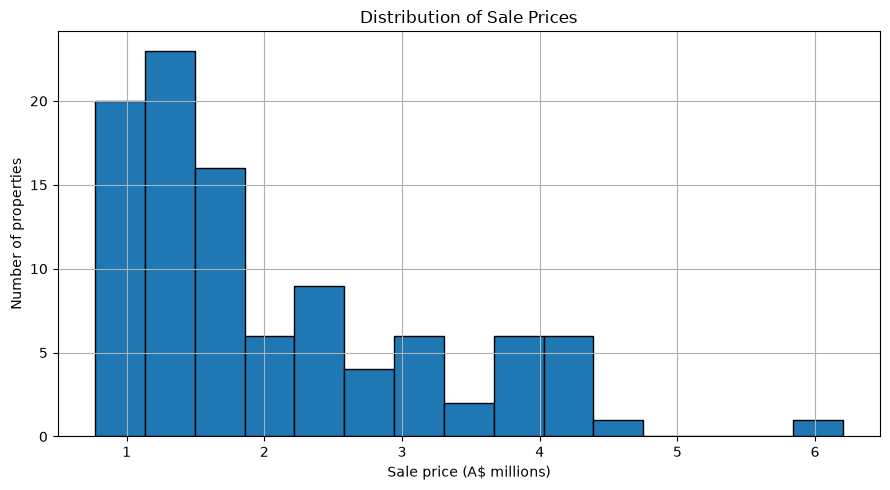

In [6]:
# Part 2.1 — Sale price distribution
plt.figure()
plt.hist(df["Sale Price"] / 1_000_000, bins=15, edgecolor="black")
plt.xlabel("Sale price (A$ millions)")
plt.ylabel("Number of properties")
plt.title("Distribution of Sale Prices")
plt.tight_layout()
plt.show()


<Figure size 900x500 with 0 Axes>

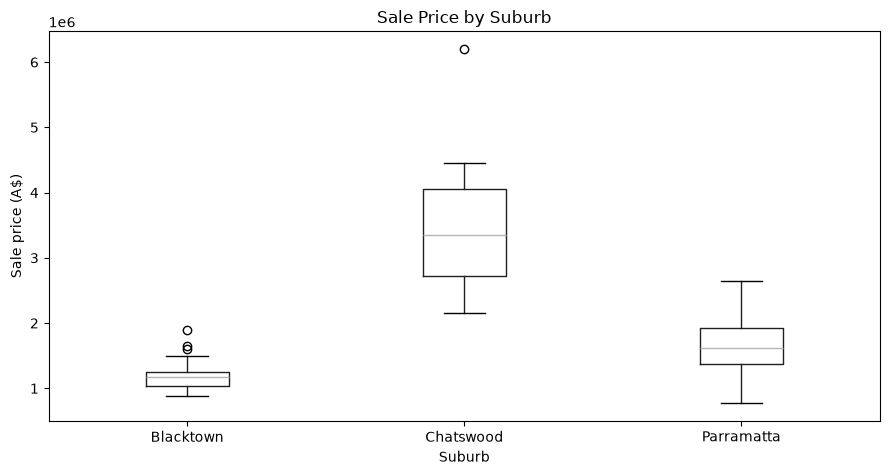

In [7]:
# Part 2.2 — Price by suburb
plt.figure()
df.boxplot(column="Sale Price", by="Suburb", grid=False)
plt.suptitle("")
plt.title("Sale Price by Suburb")
plt.xlabel("Suburb")
plt.ylabel("Sale price (A$)")
plt.tight_layout()
plt.show()


,Pearson correlation with Sale Price
Sale Price,1.000
Bathrooms,0.521
Bedrooms,0.351
Land Size (m²),0.346
Parking,0.108


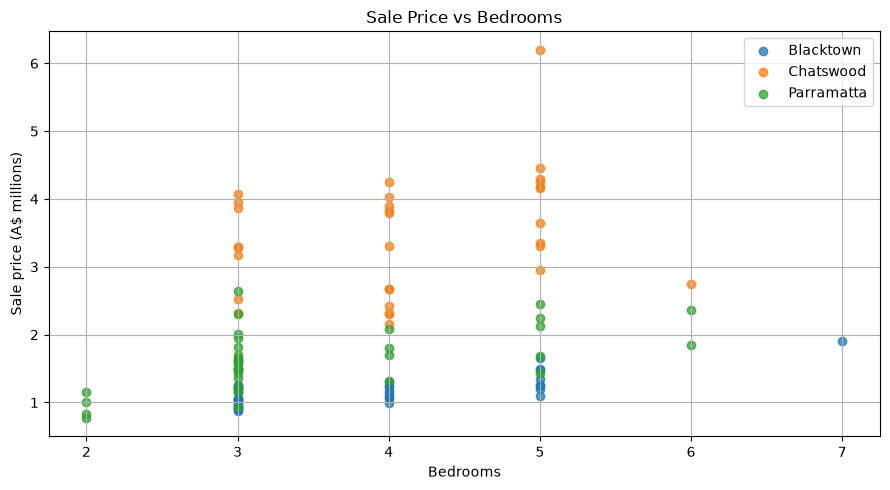

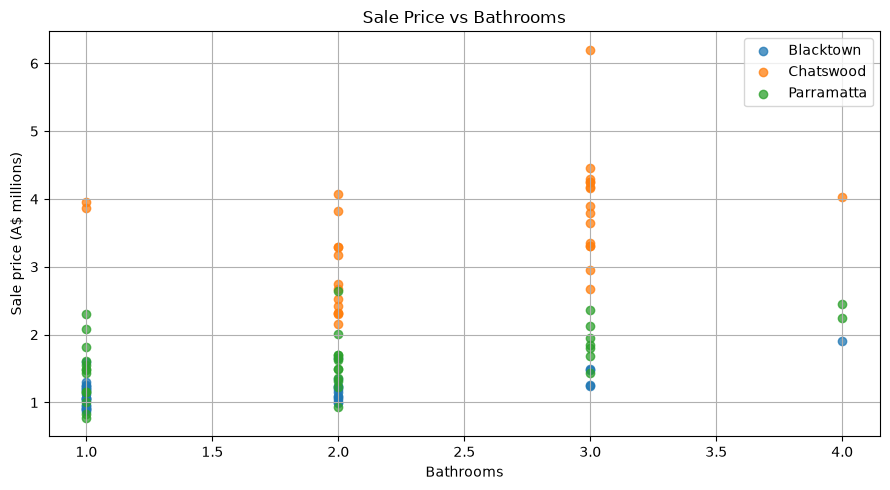

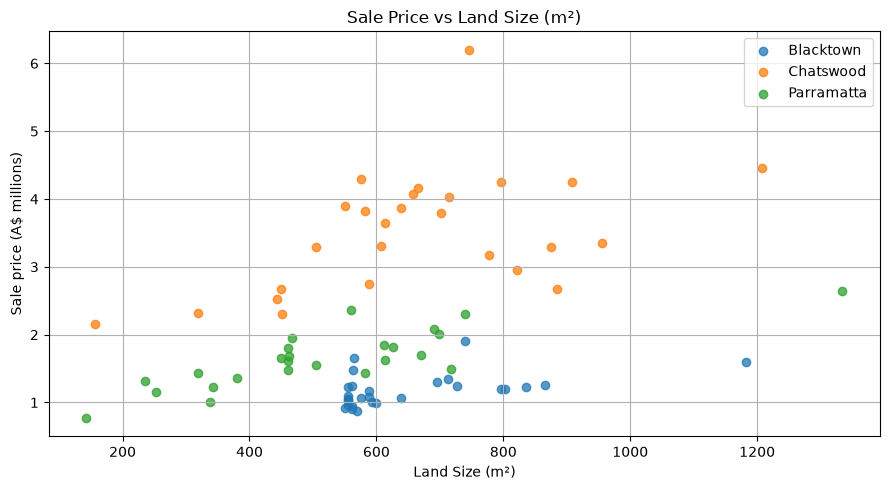

In [8]:
# Part 2.3 — Price relationships
numeric_cols = ["Bedrooms", "Bathrooms", "Parking", "Land Size (m²)", "Sale Price"]
numeric_cols = [c for c in numeric_cols if c in df.columns]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

corr = df[numeric_cols].corr(numeric_only=True)["Sale Price"].sort_values(ascending=False)
display(corr.to_frame("Pearson correlation with Sale Price"))

for feature in ["Bedrooms", "Bathrooms", "Land Size (m²)"]:
    if feature in df.columns:
        plot_df = df[[feature, "Sale Price", "Suburb"]].dropna()
        plt.figure()
        for suburb, g in plot_df.groupby("Suburb"):
            plt.scatter(g[feature], g["Sale Price"]/1_000_000, label=suburb, alpha=.75)
        plt.xlabel(feature)
        plt.ylabel("Sale price (A$ millions)")
        plt.title(f"Sale Price vs {feature}")
        plt.legend()
        plt.tight_layout()
        plt.show()


,Properties
Sale Year,
2023,1
2024,2
2025,35
2026,62


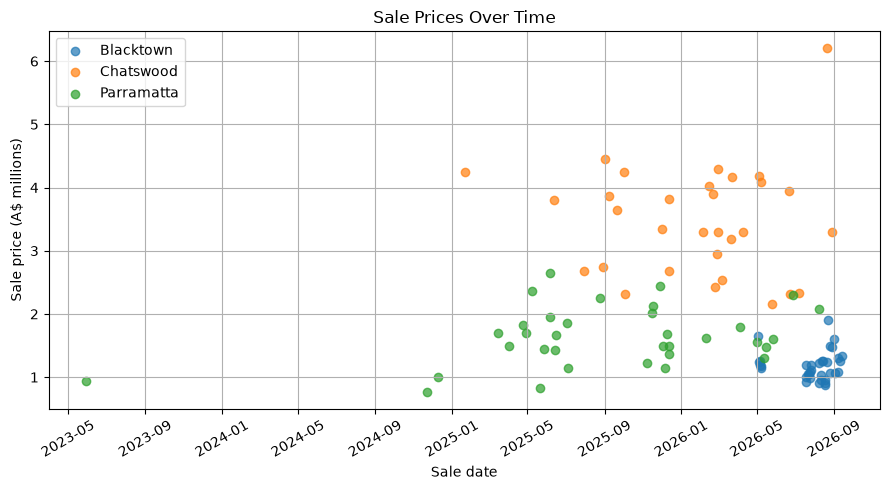

In [9]:
# Part 2.4 — Sale price over time
year_counts = df["Sale Year"].value_counts().sort_index()
display(year_counts.to_frame("Properties"))

plt.figure()
for suburb, g in df.groupby("Suburb"):
    g = g.sort_values("Sale Date")
    plt.scatter(g["Sale Date"], g["Sale Price"]/1_000_000, label=suburb, alpha=.7)
plt.xlabel("Sale date")
plt.ylabel("Sale price (A$ millions)")
plt.title("Sale Prices Over Time")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [10]:
# Part 2.5 — Outliers using the 1.5 x IQR rule
price = df["Sale Price"].dropna()
q1, q3 = price.quantile([.25, .75])
iqr = q3 - q1
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

outliers = df[(df["Sale Price"] < lower) | (df["Sale Price"] > upper)].copy()

print(f"Q1: A${q1:,.0f}")
print(f"Q3: A${q3:,.0f}")
print(f"IQR: A${iqr:,.0f}")
print(f"Upper outlier threshold: A${upper:,.0f}")
print(f"Number of IQR outliers: {len(outliers)}")
display(outliers[["ID","Suburb","Sale Date","Sale Price","Bedrooms","Bathrooms","Parking","Land Size (m²)"]])


Q1: A$1,200,000
Q3: A$2,656,250
IQR: A$1,456,250
Upper outlier threshold: A$4,840,625
Number of IQR outliers: 1


,ID,Suburb,Sale Date,Sale Price,Bedrooms,Bathrooms,Parking,Land Size (m²)
36,37,Chatswood,2026-08-21,6200000,5,3,3.000,746.100


,Missing,Missing %
Air Conditioning,100,100.000
Solar,100,100.000
Pool,100,100.000
Property Condition,100,100.000
Study,100,100.000
Building Size (m²),100,100.000
Year Built,100,100.000
Outdoor Area,100,100.000
Garage,100,100.000
Sale Method,31,31.000


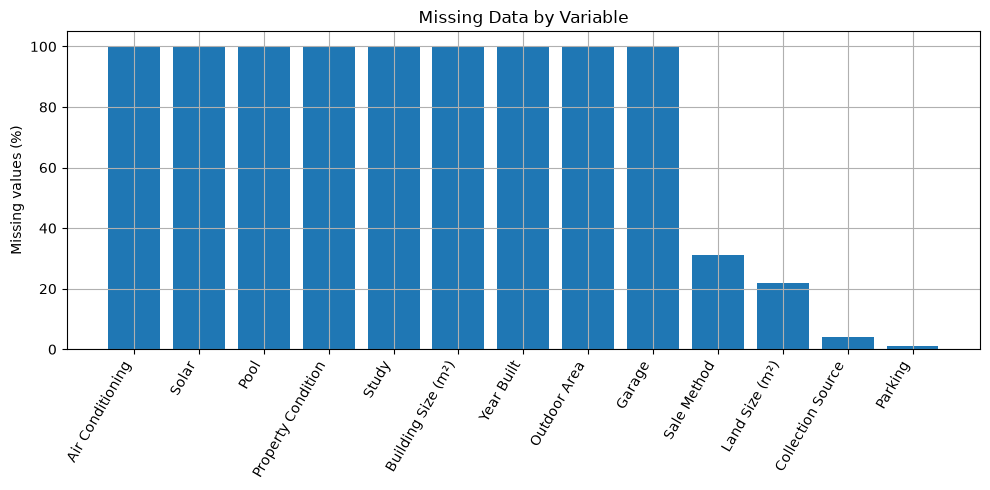

In [11]:
# Part 2.6 — Missingness
missing = pd.DataFrame({
    "Missing": df.isna().sum(),
    "Missing %": (df.isna().mean()*100).round(1)
}).sort_values("Missing", ascending=False)
display(missing)

missing_plot = missing[missing["Missing"] > 0]
if not missing_plot.empty:
    plt.figure(figsize=(10,5))
    plt.bar(missing_plot.index, missing_plot["Missing %"])
    plt.ylabel("Missing values (%)")
    plt.title("Missing Data by Variable")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()


### Initial feature hypothesis

Before model training, the expected strongest predictors are:

1. **Suburb** — captures major market-level price differences.
2. **Bathrooms** — strongest numerical correlation in the collected sample.
3. **Bedrooms** — proxy for dwelling scale and household capacity.

Land size is also expected to be useful, but its missingness requires imputation. The modelling results below will test rather than assume this hypothesis.

## Part 2.7 — Feature Engineering and Leakage-Safe Preprocessing

In [12]:
# Keep a compact feature set appropriate for n=100
candidate_features = [
    "Suburb", "Sale Method", "Bedrooms", "Bathrooms",
    "Parking", "Land Size (m²)", "Sale Year"
]
features = [c for c in candidate_features if c in df.columns]
target = "Sale Price"

X = df[features].copy()
y = df[target].copy()

categorical_features = [c for c in ["Suburb", "Sale Method"] if c in features]
numeric_features = [c for c in ["Bedrooms", "Bathrooms", "Parking", "Land Size (m²)", "Sale Year"] if c in features]

print("Features:", features)
print("Categorical:", categorical_features)
print("Numerical:", numeric_features)


Features: ['Suburb', 'Sale Method', 'Bedrooms', 'Bathrooms', 'Parking', 'Land Size (m²)', 'Sale Year']
Categorical: ['Suburb', 'Sale Method']
Numerical: ['Bedrooms', 'Bathrooms', 'Parking', 'Land Size (m²)', 'Sale Year']


In [13]:
# Preprocessing is fitted inside each model pipeline.
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
], remainder="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))


Training rows: 80
Test rows: 20


# Part 3 — Regression Models

Three different modelling approaches are compared:

- **Linear Regression:** simple linear baseline with one-hot encoded categorical variables.
- **Ridge Regression:** regularised linear model that controls coefficient magnitude and can be more stable with correlated predictors.
- **Random Forest Regressor:** nonlinear ensemble that can capture interactions and threshold effects without requiring a linear relationship.

**Pre-training expectation:** because housing prices can have nonlinear relationships with dwelling characteristics and strong suburb effects, a tree ensemble is expected to capture more complex structure. Cross-validation and held-out testing are used to assess whether that expectation is supported.

In [16]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

pipelines = {
    name: Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_rows = []
test_rows = []
fitted_models = {}

for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        "Model": name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R²": scores["test_R2"].mean(),
        "CV MAE SD": scores["test_MAE"].std(),
        "CV RMSE SD": scores["test_RMSE"].std(),
        "CV R² SD": scores["test_R2"].std()
    })

    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

    pred = pipe.predict(X_test)
    test_rows.append({
        "Model": name,
        "Test MAE": mean_absolute_error(y_test, pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "Test R²": r2_score(y_test, pred)
    })

cv_results = pd.DataFrame(cv_rows).sort_values("CV RMSE")
test_results = pd.DataFrame(test_rows).sort_values("Test RMSE")

print("5-fold cross-validation:")
display(cv_results)

print("Held-out test performance:")
display(test_results)


5-fold cross-validation:


,Model,CV MAE,CV RMSE,CV R²,CV MAE SD,CV RMSE SD,CV R² SD
0,Linear Regression,"355,191.104","498,207.165",0.764,"53,348.306","123,154.912",0.122
2,Random Forest,"386,936.252","530,750.808",0.750,"53,279.415","138,336.768",0.079
1,Ridge Regression,"417,794.809","571,509.562",0.713,"37,692.262","131,804.243",0.084


Held-out test performance:


,Model,Test MAE,Test RMSE,Test R²
0,Linear Regression,"210,346.018","290,870.888",0.912
2,Random Forest,"231,496.182","346,220.003",0.875
1,Ridge Regression,"331,976.818","446,918.490",0.792


In [17]:
# Compare CV and test RMSE
comparison = cv_results.merge(test_results, on="Model")
comparison["RMSE gap (Test - CV)"] = comparison["Test RMSE"] - comparison["CV RMSE"]
comparison["R² gap (CV - Test)"] = comparison["CV R²"] - comparison["Test R²"]
display(comparison.sort_values("CV RMSE"))


,Model,CV MAE,CV RMSE,CV R²,CV MAE SD,CV RMSE SD,CV R² SD,Test MAE,Test RMSE,Test R²,RMSE gap (Test - CV),R² gap (CV - Test)
0,Linear Regression,"355,191.104","498,207.165",0.764,"53,348.306","123,154.912",0.122,"210,346.018","290,870.888",0.912,"-207,336.278",-0.148
1,Random Forest,"386,936.252","530,750.808",0.750,"53,279.415","138,336.768",0.079,"231,496.182","346,220.003",0.875,"-184,530.805",-0.126
2,Ridge Regression,"417,794.809","571,509.562",0.713,"37,692.262","131,804.243",0.084,"331,976.818","446,918.490",0.792,"-124,591.072",-0.079


### Model evaluation guidance

Interpret the results using all metrics:

- **MAE** is the average absolute prediction error and is easy to interpret in dollars.
- **RMSE** penalises large errors more heavily, making it useful when expensive misses matter.
- **R²** describes explained variance but should not be treated as sufficient by itself.
- A large deterioration from cross-validation to the held-out test set can indicate sensitivity to the particular split.
- Random Forest has greater structural complexity than the linear models, so its performance should be considered together with the small sample size and stability across folds.

The appropriate model should be selected from the evidence rather than from the initial expectation.

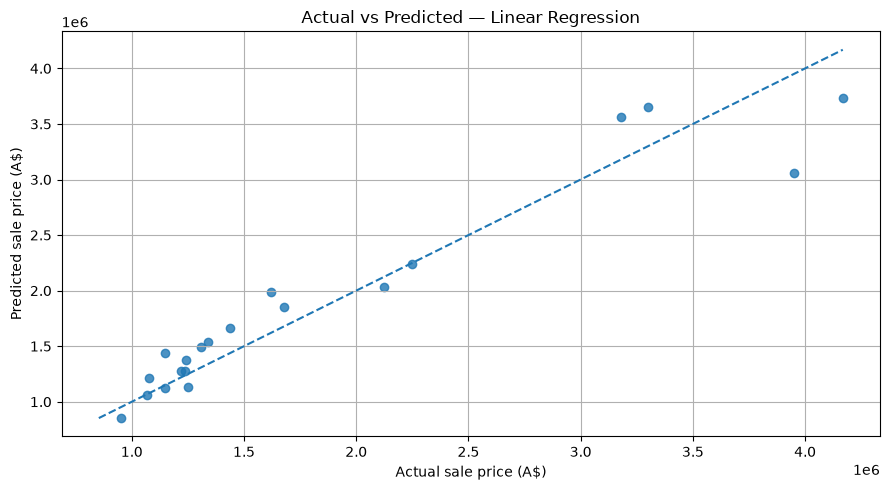

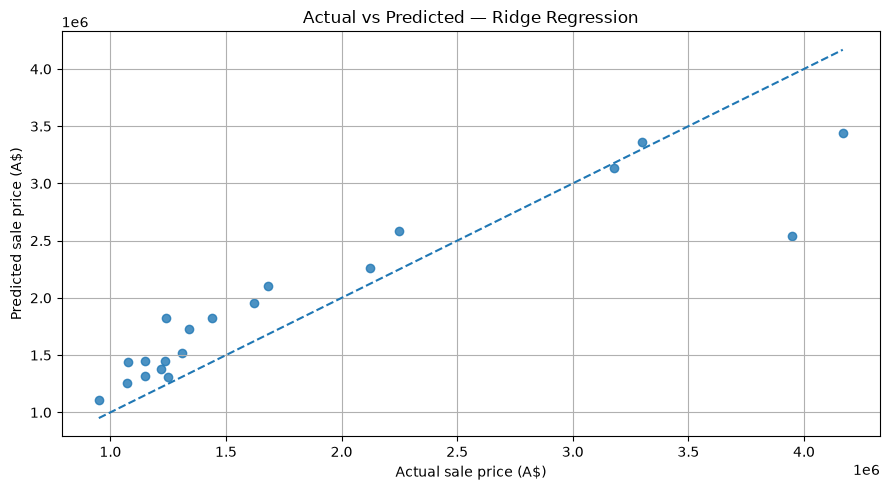

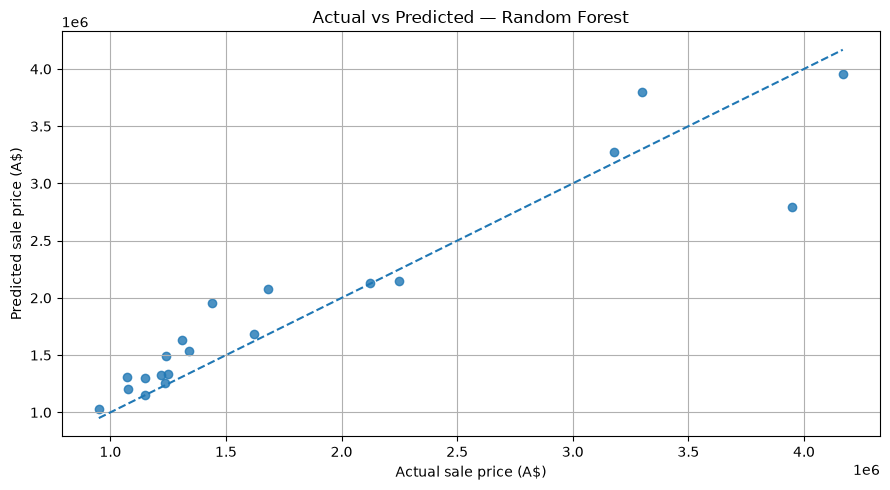

In [18]:
# Visualise actual vs predicted for every model
for name, pipe in fitted_models.items():
    pred = pipe.predict(X_test)
    plt.figure()
    plt.scatter(y_test, pred, alpha=.8)
    lo = min(y_test.min(), pred.min())
    hi = max(y_test.max(), pred.max())
    plt.plot([lo, hi], [lo, hi], linestyle="--")
    plt.xlabel("Actual sale price (A$)")
    plt.ylabel("Predicted sale price (A$)")
    plt.title(f"Actual vs Predicted — {name}")
    plt.tight_layout()
    plt.show()


## Model selection

For the downstream error analysis and application, the notebook selects the model with the **lowest mean cross-validation RMSE**, using the held-out test results as a separate generalisation check. This avoids choosing a model solely because of one test split.

In [20]:
best_model_name = cv_results.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
best_test_pred = best_model.predict(X_test)

print("Selected model based on lowest mean CV RMSE:", best_model_name)
print("Test MAE: A$", f"{mean_absolute_error(y_test, best_test_pred):,.0f}")
print("Test RMSE: A$", f"{np.sqrt(mean_squared_error(y_test, best_test_pred)):,.0f}")
print("Test R²:", f"{r2_score(y_test, best_test_pred):.3f}")


Selected model based on lowest mean CV RMSE: Linear Regression
Test MAE: A$ 210,346
Test RMSE: A$ 290,871
Test R²: 0.912


# Part 4 — Investigating the Five Largest Prediction Errors

The largest residuals are examined as cases rather than simply discarded. Large errors may reveal missing variables, unusual properties, market-specific effects or data limitations.

In [21]:
# Create test-set error table
error_df = X_test.copy()
error_df["Actual Price"] = y_test
error_df["Predicted Price"] = best_test_pred
error_df["Absolute Error"] = (error_df["Actual Price"] - error_df["Predicted Price"]).abs()
error_df["Signed Error"] = error_df["Predicted Price"] - error_df["Actual Price"]
error_df["Percentage Error"] = (
    error_df["Signed Error"].abs() / error_df["Actual Price"] * 100
)

# Attach IDs and source information
for c in ["ID", "Description", "Source URL"]:
    if c in df.columns:
        error_df[c] = df.loc[error_df.index, c]

top5_errors = error_df.sort_values("Absolute Error", ascending=False).head(5)

display(top5_errors[
    [c for c in [
        "ID","Suburb","Sale Date","Actual Price","Predicted Price",
        "Absolute Error","Percentage Error","Bedrooms","Bathrooms",
        "Parking","Land Size (m²)","ID","Description","Source URL"
    ] if c in top5_errors.columns]
])


,ID,Suburb,Actual Price,Predicted Price,Absolute Error,Percentage Error,Bedrooms,Bathrooms,Parking,Land Size (m²),ID,Description,Source URL
39,40,Chatswood,3950000,"3,061,518.590","888,481.410",22.493,3,1,2.000,NaN,40,8 Claude Street,https://www.realestate.com.au/sold/property-ho...
44,45,Chatswood,4168000,"3,737,322.977","430,677.023",10.333,5,3,2.000,665.000,45,10 Ivy Street,https://www.realestate.com.au/sold/property-ho...
45,46,Chatswood,3180000,"3,565,905.854","385,905.854",12.135,3,2,2.000,778.000,46,10 Mclean Avenue,https://www.realestate.com.au/sold/property-ho...
73,74,Parramatta,1620000,"1,989,258.887","369,258.887",22.794,3,2,2.000,613.000,74,58 Crimea Street,https://www.domain.com.au/sold-listings/parram...
53,54,Chatswood,3300000,"3,651,212.046","351,212.046",10.643,5,3,2.000,607.000,54,"17 Moola Parade, Chatswood",https://www.realestate.com.au/sold/property-ho...


### Error investigation prompts

For each of the five properties above, investigate the available source information and discuss:

- unusually high/low land size
- unusual bedroom/bathroom/parking configuration
- whether the property is an extreme value within its suburb
- whether the sale date differs from most observations
- whether the property may have characteristics not represented in the dataset
- whether missing land size or sale-method information could contribute
- whether the property is a legitimate difficult case rather than a data error

Do not infer renovations, views, development potential or condition unless the source evidence actually supports the claim.

# Part 5 — Ten Held-Out Properties: ML vs LLM vs Human

The brief asks for a comparison using ten held-out properties. This notebook creates a reproducible 10-property evaluation set.

**Important:** the LLM estimate and the student's own estimate must be genuine estimates made from the same information available to the ML model. They are therefore left as input fields rather than invented.

In [29]:
# Part 5 — Create a genuine 10-property ML holdout

from sklearn.base import clone

rng = np.random.RandomState(RANDOM_STATE)

# X_train contains the original 80 training observations.
# Select 10 of those as the Part 5 holdout.
holdout10_indices = rng.choice(
    X_train.index,
    size=10,
    replace=False
)

# The other 70 observations are used to train the Part 5 model.
part5_train_indices = X_train.index.difference(holdout10_indices)

X_part5_train = X.loc[part5_train_indices, features].copy()
y_part5_train = y.loc[part5_train_indices].copy()

X_part5_holdout = X.loc[holdout10_indices, features].copy()
y_part5_holdout = y.loc[holdout10_indices].copy()

# Create a fresh copy of the selected model
part5_model = Pipeline([
    ("preprocess", clone(preprocessor)),
    ("model", clone(models[best_model_name]))
])

# Train only on the 70 Part 5 training properties
part5_model.fit(
    X_part5_train,
    y_part5_train
)

# Predict the 10 properties the model has never seen
part5_predictions = part5_model.predict(
    X_part5_holdout
)

# Build the Part 5 table
holdout10 = df.loc[
    holdout10_indices,
    [
        c for c in [
            "ID",
            "Suburb",
            "Sale Date",
            "Sale Price",
            "Bedrooms",
            "Bathrooms",
            "Parking",
            "Land Size (m²)",
            "Sale Method",
            "Source URL"
        ]
        if c in df.columns
    ]
].copy()

holdout10["ML Prediction"] = part5_predictions

# These will be entered later
llm_estimates = {
    25: 1100000,
    56: 3000000,
    8: 1050000,
    4: 1450000,
    36: 2200000,
    63: 3500000,
    12: 1100000,
    92: 850000,
    70: 1250000,
    86: 2000000
}

your_estimates = {
    25: 1200000,
    56: 3250000,
    8: 1075000,
    4: 1250000,
    36: 2350000,
    63: 3750000,
    12: 1250000,
    92: 950000,
    70: 1300000,
    86: 2500000
}

holdout10["LLM Estimate"] = holdout10["ID"].map(llm_estimates)
holdout10["Your Estimate"] = holdout10["ID"].map(your_estimates)

# ML errors
holdout10["ML Absolute Error"] = (
    holdout10["ML Prediction"] -
    holdout10["Sale Price"]
).abs()

holdout10["ML Percentage Error"] = (
    holdout10["ML Absolute Error"] /
    holdout10["Sale Price"]
) * 100

print("Part 5 training properties:", len(part5_train_indices))
print("Part 5 held-out properties:", len(holdout10_indices))
print("Part 3 test properties kept separate:", len(X_test))

display(holdout10)

Part 5 training properties: 70
Part 5 held-out properties: 10
Part 3 test properties kept separate: 20


,ID,Suburb,Sale Date,Sale Price,Bedrooms,Bathrooms,Parking,Land Size (m²),Sale Method,Source URL,ML Prediction,LLM Estimate,Your Estimate,ML Absolute Error,ML Percentage Error
24,25,Blacktown,2026-07-23,1050000,3,2,1.000,NaN,Private treaty,https://www.domain.com.au/sold-listings/blackt...,"1,034,018.626",1100000,1200000,"15,981.374",1.522
55,56,Chatswood,2025-12-12,2675000,4,2,1.000,885.000,NaN,https://www.realestate.com.au/sold/property-ho...,"3,689,845.472",3000000,3250000,"1,014,845.472",37.938
7,8,Blacktown,2026-08-26,1062500,3,1,1.000,575.000,Private treaty,https://www.domain.com.au/sold-listings/blackt...,"883,127.189",1050000,1075000,"179,372.811",16.882
3,4,Blacktown,2026-09-08,1089000,5,2,2.000,556.000,Private treaty,https://www.domain.com.au/sold-listings/blackt...,"1,306,507.670",1450000,1250000,"217,507.670",19.973
35,36,Chatswood,2026-08-29,3290000,3,2,2.000,505.000,NaN,https://www.realestate.com.au/sold/property-ho...,"3,111,283.106",2200000,2350000,"178,716.894",5.432
62,63,Chatswood,2025-08-30,2750000,6,2,2.000,588.000,NaN,https://www.realestate.com.au/sold/property-ho...,"3,553,521.376",3500000,3750000,"803,521.376",29.219
11,12,Blacktown,2026-08-18,880000,3,1,2.000,569.000,Private treaty,https://www.domain.com.au/sold-listings/blackt...,"871,760.231",1100000,1250000,"8,239.769",0.936
91,92,Parramatta,2025-05-21,830000,2,1,NaN,NaN,Private treaty,https://www.domain.com.au/sold-listings/parram...,"1,408,514.556",850000,950000,"578,514.556",69.701
69,70,Parramatta,2026-05-16,1480000,3,1,1.000,461.000,Private treaty,https://www.domain.com.au/sold-listings/parram...,"1,548,440.627",1250000,1300000,"68,440.627",4.624
85,86,Parramatta,2025-07-03,1850000,6,3,2.000,612.000,Private treaty,https://www.domain.com.au/sold-listings/parram...,"2,355,143.988",2000000,2500000,"505,143.988",27.305


### How to complete the LLM and human columns

For each of the 10 properties:

1. Give the LLM **only the same structured features** available to the ML model.
2. Record the LLM's estimated sale price in `LLM Estimate`.
3. Independently estimate the price yourself using the same information.
4. Enter your value in `Your Estimate`.
5. Re-run the evaluation cell below.

Do not use the actual sale price as part of either estimate.

In [30]:
# Part 5 comparison — ML vs LLM vs Human

comparison10 = holdout10.copy()

for method, col in [
    ("ML", "ML Prediction"),
    ("LLM", "LLM Estimate"),
    ("Human", "Your Estimate")
]:
    comparison10[f"{method} Absolute Error"] = (
        comparison10[col] -
        comparison10["Sale Price"]
    ).abs()

    comparison10[f"{method} Percentage Error"] = (
        comparison10[f"{method} Absolute Error"] /
        comparison10["Sale Price"]
    ) * 100


def calculate_rmse(actual, predicted):
    valid = actual.notna() & predicted.notna()

    if not valid.any():
        return np.nan

    return np.sqrt(
        mean_squared_error(
            actual[valid],
            predicted[valid]
        )
    )


summary10 = pd.DataFrame({
    "Method": ["ML", "LLM", "Human"],

    "MAE": [
        comparison10["ML Absolute Error"].mean(),
        comparison10["LLM Absolute Error"].mean(),
        comparison10["Human Absolute Error"].mean()
    ],

    "RMSE": [
        calculate_rmse(
            comparison10["Sale Price"],
            comparison10["ML Prediction"]
        ),

        calculate_rmse(
            comparison10["Sale Price"],
            comparison10["LLM Estimate"]
        ),

        calculate_rmse(
            comparison10["Sale Price"],
            comparison10["Your Estimate"]
        )
    ]
})

display(comparison10)
display(summary10)

,ID,Suburb,Sale Date,Sale Price,Bedrooms,Bathrooms,Parking,Land Size (m²),Sale Method,Source URL,ML Prediction,LLM Estimate,Your Estimate,ML Absolute Error,ML Percentage Error,LLM Absolute Error,LLM Percentage Error,Human Absolute Error,Human Percentage Error
24,25,Blacktown,2026-07-23,1050000,3,2,1.000,NaN,Private treaty,https://www.domain.com.au/sold-listings/blackt...,"1,034,018.626",1100000,1200000,"15,981.374",1.522,50000,4.762,150000,14.286
55,56,Chatswood,2025-12-12,2675000,4,2,1.000,885.000,NaN,https://www.realestate.com.au/sold/property-ho...,"3,689,845.472",3000000,3250000,"1,014,845.472",37.938,325000,12.150,575000,21.495
7,8,Blacktown,2026-08-26,1062500,3,1,1.000,575.000,Private treaty,https://www.domain.com.au/sold-listings/blackt...,"883,127.189",1050000,1075000,"179,372.811",16.882,12500,1.176,12500,1.176
3,4,Blacktown,2026-09-08,1089000,5,2,2.000,556.000,Private treaty,https://www.domain.com.au/sold-listings/blackt...,"1,306,507.670",1450000,1250000,"217,507.670",19.973,361000,33.150,161000,14.784
35,36,Chatswood,2026-08-29,3290000,3,2,2.000,505.000,NaN,https://www.realestate.com.au/sold/property-ho...,"3,111,283.106",2200000,2350000,"178,716.894",5.432,1090000,33.131,940000,28.571
62,63,Chatswood,2025-08-30,2750000,6,2,2.000,588.000,NaN,https://www.realestate.com.au/sold/property-ho...,"3,553,521.376",3500000,3750000,"803,521.376",29.219,750000,27.273,1000000,36.364
11,12,Blacktown,2026-08-18,880000,3,1,2.000,569.000,Private treaty,https://www.domain.com.au/sold-listings/blackt...,"871,760.231",1100000,1250000,"8,239.769",0.936,220000,25.000,370000,42.045
91,92,Parramatta,2025-05-21,830000,2,1,NaN,NaN,Private treaty,https://www.domain.com.au/sold-listings/parram...,"1,408,514.556",850000,950000,"578,514.556",69.701,20000,2.410,120000,14.458
69,70,Parramatta,2026-05-16,1480000,3,1,1.000,461.000,Private treaty,https://www.domain.com.au/sold-listings/parram...,"1,548,440.627",1250000,1300000,"68,440.627",4.624,230000,15.541,180000,12.162
85,86,Parramatta,2025-07-03,1850000,6,3,2.000,612.000,Private treaty,https://www.domain.com.au/sold-listings/parram...,"2,355,143.988",2000000,2500000,"505,143.988",27.305,150000,8.108,650000,35.135


,Method,MAE,RMSE
0,ML,"357,028.454","488,040.860"
1,LLM,"320,850.000","459,717.549"
2,Human,"415,850.000","535,630.680"


### Part 5 discussion framework

Discuss the three approaches without assuming that one method is universally superior.

**Machine learning:** benefits from systematic fitting to historical examples and consistent application of the same rules, but is limited by the sample, feature availability and distribution of the training data.

**LLM estimate:** can synthesise contextual descriptions if supplied, but its numerical estimate may not be calibrated to a specific local market and can be sensitive to prompting and information selection.

**Human estimate:** can incorporate qualitative judgement and local/contextual reasoning, but is subjective and can suffer from anchoring or inconsistent use of evidence.

The useful question is how each method behaves on the ten cases and what information each method can or cannot access.

# Part 6 — Decision Support Web App

The app below is designed for Streamlit. It accepts the same core inputs used by the final model and returns a predicted sale price.

The deployment workflow is:

1. Train the final pipeline on the complete modelling dataset.
2. Save it with `joblib`.
3. Run `streamlit run app.py` locally.
4. Deploy the repository to a Streamlit-compatible hosting service or another accessible platform.
5. Document the URL and include screenshots in the report.

In [26]:
# Train final model on all 100 observations and save the pipeline for the app
import joblib

final_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", models[best_model_name])
])

final_pipeline.fit(X, y)

MODEL_PATH = "/mnt/data/sydney_house_price_model.joblib"
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

joblib.dump(
    {
        "pipeline": final_pipeline,
        "features": features,
        "categorical_features": categorical_features,
        "numeric_features": numeric_features,
        "model_name": best_model_name
    },
    MODEL_PATH
)

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model was not saved: {MODEL_PATH}")

print("Saved model:", MODEL_PATH)


Saved model: /mnt/data/sydney_house_price_model.joblib


## App usage

Suggested user flow:

- Select suburb.
- Enter bedrooms, bathrooms and parking.
- Enter land size where known; otherwise leave it blank.
- Select sale method where known.
- Enter sale year.
- Click **Predict Sale Price**.
- Treat the result as a model-based estimate, not an official valuation.

For deployment, the app should also display a concise limitation notice covering sample size, selected suburbs, missing variables and uncertainty.

## Project Resources

**GitHub Repository:**  
https://github.com/YoggJoshi7/SIT720-Sydney-Housing-Price-Prediction

**Deployed Streamlit Application:**  
https://sit720-sydney-housing-price-prediction.streamlit.app/